In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import torch
import matplotlib.pyplot as plt

from Lasso import LassoRegression

In [22]:
def generate_lasso_data(
    n=100,          # sample number
    d=20,           # feature number
    k=5,            # useful feature number
    noise_std=0.1,  # noise
    seed=42
):
    torch.manual_seed(seed)

    X = torch.randn(n, d)
    w_true = torch.zeros(d, 1)

    idx = torch.randperm(d)[:k]
    w_true[idx] = torch.randn(k, 1) * 5   
    b_true = torch.randn(1)

    y = X @ w_true + b_true
    y += noise_std * torch.randn(n, 1)

    return X, y, w_true, b_true

X, y, w_true, b_true=generate_lasso_data()

# Lasso Regression

In [23]:
lasso=LassoRegression(lam=1)
lasso.train(X,y)

print(lasso.w_hat)
print(w_true,b_true)

Iter 0 | Loss: 294.657623
Iter 1 | Loss: 283.307648
Iter 2 | Loss: 273.432953
Iter 3 | Loss: 264.037262
Iter 4 | Loss: 255.094543
Iter 5 | Loss: 246.580124
Iter 6 | Loss: 238.470779
Iter 7 | Loss: 230.744690
Iter 8 | Loss: 223.382523
Iter 9 | Loss: 216.364349
Iter 10 | Loss: 209.669128
Iter 11 | Loss: 203.281754
Iter 12 | Loss: 197.185806
Iter 13 | Loss: 191.366043
Iter 14 | Loss: 185.807983
Iter 15 | Loss: 180.498001
Iter 16 | Loss: 175.423279
Iter 17 | Loss: 170.571625
Iter 18 | Loss: 165.931580
Iter 19 | Loss: 161.493256
Iter 20 | Loss: 157.247925
Iter 21 | Loss: 153.180298
Iter 22 | Loss: 149.284546
Iter 23 | Loss: 145.552063
Iter 24 | Loss: 141.974716
Iter 25 | Loss: 138.544846
Iter 26 | Loss: 135.255188
Iter 27 | Loss: 132.098877
Iter 28 | Loss: 129.070389
Iter 29 | Loss: 126.165604
Iter 30 | Loss: 123.371735
Iter 31 | Loss: 120.687302
Iter 32 | Loss: 118.107086
Iter 33 | Loss: 115.626183
Iter 34 | Loss: 113.239929
Iter 35 | Loss: 110.943901
Iter 36 | Loss: 108.738281
Iter 37 | L

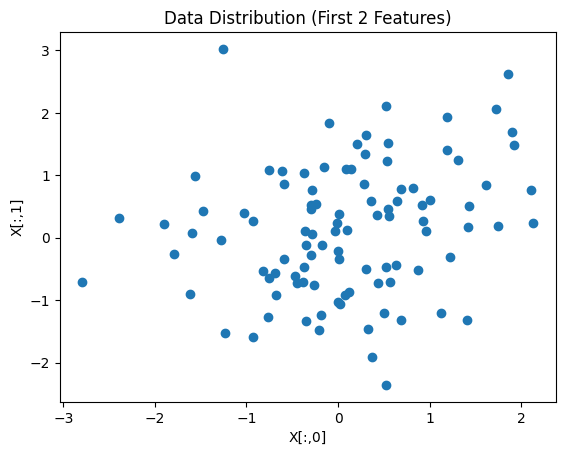

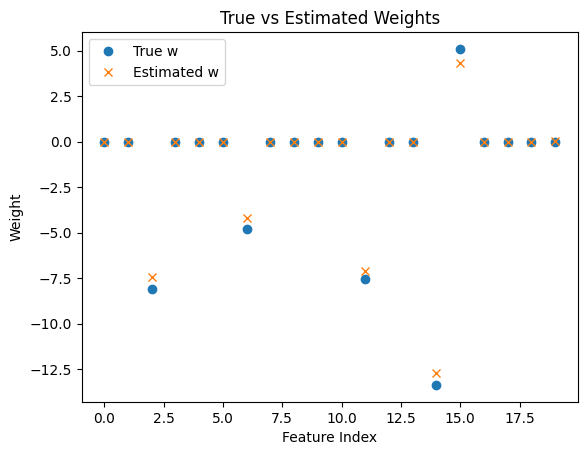

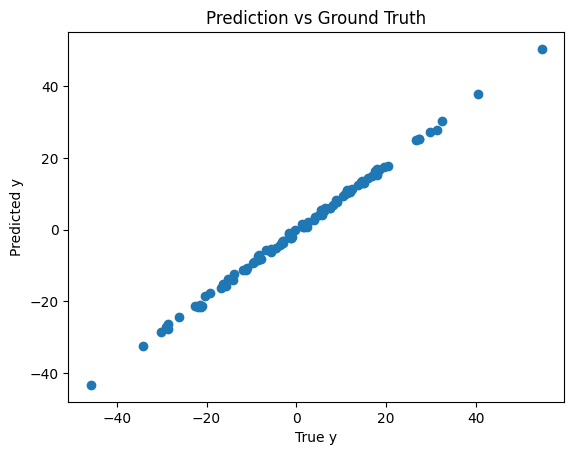

In [24]:
def visualize_lasso(X, y, w_true, model):
    w_est = model.w_hat[:-1].detach()
    y_pred = model.predict(X).detach()

    plt.figure()
    plt.scatter(X[:, 0].numpy(), X[:, 1].numpy())
    plt.title("Data Distribution (First 2 Features)")
    plt.xlabel("X[:,0]")
    plt.ylabel("X[:,1]")
    plt.show()

    plt.figure()
    plt.plot(w_true.numpy(), marker='o', linestyle='none', label="True w")
    plt.plot(w_est.numpy(), marker='x', linestyle='none', label="Estimated w")
    plt.legend()
    plt.title("True vs Estimated Weights")
    plt.xlabel("Feature Index")
    plt.ylabel("Weight")
    plt.show()

    plt.figure()
    plt.scatter(y.numpy(), y_pred.numpy())
    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title("Prediction vs Ground Truth")
    plt.show()

visualize_lasso(X, y, w_true, lasso)